# 07 — Latent regression model of turnout (PLS)

This is the priority notebook in the rewrite: it fits the **partial least squares (PLS) latent-variable regression** that the earlier, much larger exploration (dozens of scripts under the archived `modelling/dimension_reduction/` tree) eventually converged on as the preferred way to summarize what drives CT-level voter turnout in Toronto.

**Why PLS, briefly:** the predictor blocks (age/life stage, household and family structure, education, labour market and occupation, income and class, housing tenure/form/affordability and need, immigration and citizenship, culture and language, transportation, and urban form/accessibility) are highly collinear with each other — e.g. renters, apartment share, and population density all move together. Ordinary regression on all of them at once is unstable. PLS instead extracts a small number of *components* — linear combinations of the predictors — chosen specifically to covary with turnout, so we get a handful of interpretable "social-geography axes" instead of dozens of shaky individual coefficients.

**What changed in this version:** earlier work (and the first draft of this notebook) fit PLS on a hand-picked, 14-variable shortlist nicknamed "the meeting PLS." Notebook 06 has since built a much broader, systematically curated predictor pool — 70 variables across 14 thematic families, with the exclusions and redundancy calls documented in `predictor_metadata.csv`. This notebook widens the model to that full curated pool. **The algorithm itself is untouched** — same NIPALS implementation, same component-selection procedure, same CV seed — only the predictor list is wider. The point is to see what the same, already-trusted method says once it can see the whole curated picture, not to change how it looks.

**What's in this notebook:**
1. Load the model-input table built in notebook 06 (`ct_model_input.csv`) and the curated predictor list (`predictor_metadata.csv`) — the default `PREDICTORS` are read **dynamically** from that metadata file, not hardcoded, so this notebook stays in sync automatically if notebook 06 is revised.
2. The PLS fitting algorithm itself (NIPALS), byte-for-byte the same as before.
3. Cross-validated component selection, variable importance (VIP), and component loadings — now broken out by predictor *family* so it's immediately legible which theme dominates each component.
4. Plain-language interpretation of each retained component, "reference geographies," a full per-CT export of component scores, and a map of the leading component.
5. An **internal consistency check**, not a headline result: the original 14-variable "meeting PLS" is refit inside this same notebook, using the exact same shared plumbing (`fit_pls`, `choose_components`, …), and compared against the archived `meeting_pls_*` ground truth. This answers "did widening the predictor pool, or anything upstream, quietly break the shared machinery?" — it is not meant to be read as a second finding about turnout.

Everything from the NIPALS implementation onward is generic to whatever predictor list sits in `PREDICTORS` — swap the metadata-driven default for something else and the rest re-runs unchanged.

In [1]:
from __future__ import annotations

import math
import re
from dataclasses import dataclass
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from tqdm.notebook import tqdm

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)

In [2]:
# --- Paths -------------------------------------------------------------
REPO_ROOT = Path.cwd().resolve().parents[1]
FEATURES_ROOT = REPO_ROOT / "data/toronto_election_turnout/features"
INPUT_PATH = FEATURES_ROOT / "ct_model_input.csv"
METADATA_PATH = FEATURES_ROOT / "predictor_metadata.csv"
GEOJSON_PATH = FEATURES_ROOT / "ct_model_input.geojson"
OUTPUT_ROOT = REPO_ROOT / "data/toronto_election_turnout/model"

# Archived ground truth for the *original* 14-variable model, read-only, used only
# in the internal-consistency-check section near the end.
ARCHIVE_MODEL_ROOT = REPO_ROOT / "analysis/toronto_election_turnout/data/archive/modelling/processed/dimension_reduction/meeting_PLS/meeting_pls_model"

# --- Target --------------------------------------------------------------
TARGET = "mean_turnout"

# --- Predictor list, read dynamically from notebook 06's curated metadata ---
# `predictor_metadata.csv` has one row per variable considered; family == "excluded"
# rows were deliberately dropped (redundant, zero-variance, or election-mechanics
# variables kept in ct_model_input.csv only for notebook 08). Everything else is
# the curated predictor pool. This is still an editable list in spirit — swap
# `PREDICTORS` for a different theory-driven set and everything below re-runs
# generically — but the *default* is derived from the metadata file so it can't
# silently drift out of sync with notebook 06.
predictor_metadata = pd.read_csv(METADATA_PATH)
predictor_metadata_active = predictor_metadata[predictor_metadata["family"] != "excluded"].copy()

PREDICTORS = predictor_metadata_active["variable"].tolist()

# {family: [variables]}, derived directly from the metadata file (not hand-copied).
FAMILIES = {
    family: group["variable"].tolist()
    for family, group in predictor_metadata_active.groupby("family", sort=False)
}
VARIABLE_FAMILY = dict(zip(predictor_metadata_active["variable"], predictor_metadata_active["family"]))

print(f"{len(PREDICTORS)} predictors across {len(FAMILIES)} families (read from {METADATA_PATH.name}):")
for family, variables in FAMILIES.items():
    print(f"  {family:38s} {len(variables):2d}")

# --- PLS fitting parameters (match the archived run exactly, for comparability) ---
MAX_COMPONENTS = 12
CV_FOLDS = 10
RANDOM_SEED = 20260803

# --- Cosmetic lookups, used only for readable output/plots, never for fitting ---
# Default plain name: strip the blockN_ prefix, underscores -> spaces. Only a
# handful of variables read awkwardly that way and get a hand-written override.
# This round's curated pool is a fixed 70 variables across 14 families, so every
# one of them gets an explicit entry here rather than relying on the fallback.
PLAIN_NAME_OVERRIDES = {
    # age_life_stage
    "block1_age_18_29_share": "age 18-29 share",
    "block1_age_30_64_share": "age 30-64 share",
    "block1_age_65_plus_share": "age 65+ share",
    "block5_school_age_5_17_share": "school-age (5-17) share",
    # household_family
    "block1_average_household_size": "average household size",
    "block1_one_person_household_share": "one-person household share",
    "block1_one_parent_family_share": "one-parent family share",
    "block1_multigenerational_household_share": "multigenerational household share",
    "block1_married_or_common_law_share": "married or common-law share",
    "block1_never_married_share": "never-married share",
    # education
    "block1_bachelors_or_higher_25_64_share": "bachelor's degree or higher (25-64) share",
    "block1_college_or_trades_25_64_share": "college or trades credential (25-64) share",
    "block1_high_school_or_less_share": "high school or less share",
    # income_class
    "block1_median_household_income": "median household income",
    "block1_low_income_lim_at_share": "low income (LIM-AT) share",
    # labour_market
    "block1_employment_rate_share": "employment rate",
    "block1_unemployment_rate_share": "unemployment rate",
    "block1_not_in_labour_force_share": "not in labour force share",
    "block1_temporary_worker_share": "temporary worker share",
    "block1_self_employment_share": "self-employment share",
    # occupation
    "block1_occ_management_share": "management occupation share",
    "block1_occ_business_finance_admin_share": "business, finance, and administration occupation share",
    "block1_occ_education_law_social_gov_share": "education, law, and social/government services occupation share",
    "block1_occ_natural_applied_sciences_share": "natural and applied sciences occupation share",
    "block1_occ_sales_service_share": "sales and service occupation share",
    "block1_occ_trades_transport_share": "trades and transport occupation share",
    "block1_occ_manufacturing_share": "manufacturing occupation share",
    "block1_occ_arts_recreation_sport_share": "arts, recreation, and sport occupation share",
    # housing_tenure_stability
    "block2_renter_share": "renter share",
    "block2_same_address_5yr_share": "same address 5 years ago share",
    "block2_recent_mover_share": "recent mover (past year) share",
    # housing_form
    "block2_apartment_share": "apartment share",
    "block2_condo_share": "condo share",
    "block2_detached_share": "detached house share",
    "block2_high_rise_apartment_share": "high-rise apartment share",
    "block2_dwelling_vintage_pre1960_share": "dwellings built before 1960 share",
    "block2_dwelling_vintage_1961_1990_share": "dwellings built 1961-1990 share",
    # housing_affordability_need
    "block2_shelter_cost_burden_30plus_share": "shelter cost burden (30%+) share",
    "block2_core_housing_need_share": "core housing need share",
    "block5_social_housing_share": "social housing share",
    "block2_dwelling_major_repairs_needed_share": "dwelling needs major repairs share",
    # immigration_citizenship
    "block3_immigrant_share": "immigrant share",
    "block3_recent_immigrant_share": "recent immigrant share",
    "block3_non_citizen_share": "non-citizen share",
    "block3_first_generation_share": "first-generation Canadian share",
    "block3_second_generation_share": "second-generation Canadian share",
    # culture_language
    "block3_visible_minority_share": "visible minority share",
    "block3_no_religion_share": "no religious affiliation share",
    "block3_non_official_language_at_home_share": "non-official language at home share",
    "block3_neither_english_nor_french_share": "neither English nor French share",
    # transportation
    "block5_tts_no_car_household_share": "TTS no-car household share",
    "block5_tts_vehicles_per_household": "TTS vehicles per household",
    "block5_tts_transit_trip_share": "TTS transit trip share",
    "block5_tts_auto_trip_share": "TTS auto trip share",
    "block5_tts_walk_or_bike_trip_share": "TTS walk or bike trip share",
    "block5_tts_avg_trip_distance_km": "TTS average trip distance (km)",
    "block5_tts_trips_per_person": "TTS trips per person",
    "block5_census_long_commute_60min_share": "long commute (60+ minutes) share",
    "block5_census_work_from_home_share": "work from home share",
    # urban_form
    "block2_population_density_per_km2": "population density (per km²)",
    "block5_distance_city_hall_km": "distance to city hall (km)",
    # accessibility
    "block5_jobs_proximity_index": "jobs proximity index",
    "block5_transit_proximity_index": "transit proximity index",
    "block5_grocery_proximity_index": "grocery proximity index",
    "block5_health_care_proximity_index": "health care proximity index",
    "block5_childcare_proximity_index": "childcare proximity index",
    "block5_elementary_school_proximity_index": "elementary school proximity index",
    "block5_secondary_school_proximity_index": "secondary school proximity index",
    "block5_library_proximity_index": "library proximity index",
    "block5_parks_proximity_index": "park proximity index",
}


def plain_name(variable: str) -> str:
    if variable in PLAIN_NAME_OVERRIDES:
        return PLAIN_NAME_OVERRIDES[variable]
    return re.sub(r"^block\d+_", "", variable).replace("_", " ")


def variable_family(variable: str) -> str:
    return VARIABLE_FAMILY.get(variable, "other")


def family_label(family: str) -> str:
    return family.replace("_", " ")


# Fixed categorical color per family (assigned in a stable order, never re-cycled
# as predictors are filtered/sorted) so family color means the same thing in
# every chart in this notebook. This round's curation split the prior round's 8
# broad families into 14 narrower ones; related sub-families (e.g. education /
# labour_market / occupation, all descended from the old "education_labour_class")
# share a hue, differentiated by shade, so the family groupings they came from are
# still visually legible. Note: with 14 categories on one chart, color is a
# secondary cue only -- the y-axis plain-name label and the legend are what
# actually identify each bar; full pairwise colorblind-safe separation isn't
# achievable at this count (see the dataviz skill's categorical-palette notes).
FAMILY_COLORS = {
    "age_life_stage": "#2a78d6",
    "household_family": "#eb6834",
    "education": "#1baf7a",
    "labour_market": "#0d7a52",
    "occupation": "#7fe0b8",
    "income_class": "#eda100",
    "housing_tenure_stability": "#e87ba4",
    "housing_form": "#b43d6e",
    "housing_affordability_need": "#f5b8d0",
    "immigration_citizenship": "#008300",
    "culture_language": "#5cb85c",
    "transportation": "#4a3aa7",
    "urban_form": "#e34948",
    "accessibility": "#8f2524",
}
DIVERGING_CMAP = LinearSegmentedColormap.from_list("diverging_blue_red", ["#2a78d6", "#f0efec", "#e34948"])

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

70 predictors across 14 families (read from predictor_metadata.csv):
  age_life_stage                          4
  household_family                        6
  education                               3
  income_class                            2
  labour_market                           5
  occupation                              8
  housing_tenure_stability                3
  housing_form                            6
  housing_affordability_need              4
  immigration_citizenship                 5
  culture_language                        4
  transportation                          9
  urban_form                              2
  accessibility                           9


## Load the model-input table

This is the 585-CT feature table built in notebook 06 — Blocks 1–5 joined and curated. We just check that the predictors and target we asked for are actually present and finite.

In [3]:
df = pd.read_csv(INPUT_PATH)
print(f"Loaded {len(df)} CTs, {df.shape[1]} columns from {INPUT_PATH.relative_to(REPO_ROOT)}")

missing = [v for v in PREDICTORS if v not in df.columns]
if missing:
    raise ValueError(f"Missing predictors in ct_model_input.csv: {missing}")
if TARGET not in df.columns:
    raise ValueError(f"Missing target column: {TARGET}")

x_all = df[PREDICTORS].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
y_all = pd.to_numeric(df[TARGET], errors="coerce").to_numpy(dtype=float)
keep = np.isfinite(y_all) & np.isfinite(x_all).all(axis=1)
print(f"{keep.sum()} of {len(df)} CTs have complete data on all {len(PREDICTORS)} predictors + target")

x = x_all[keep]
y = y_all[keep]
df_model = df.loc[keep].reset_index(drop=True)

Loaded 585 CTs, 204 columns from data/toronto_election_turnout/features/ct_model_input.csv
585 of 585 CTs have complete data on all 70 predictors + target


## The PLS algorithm (NIPALS)

We fit PLS1 (single outcome) using the NIPALS algorithm, ported directly from the archived workflow so results are numerically comparable to the earlier analysis. **Unchanged from the original 14-variable notebook** — this is the exact same implementation, just handed a wider `x`:

1. Standardize `x` and `y` to mean 0 / std 1 (population std, `ddof=0`; a zero-variance predictor gets `std=1` so it doesn't blow up).
2. Each component: find the weight vector `w` most aligned with `x.T @ y` (i.e. the direction in predictor-space that best covaries with the outcome), project `x` onto it to get scores `t`, then **deflate** both `x` and `y` by removing what that component explains, before extracting the next one.
3. Repeat until we hit the requested number of components, `x` runs out of predictors, or a component's signal drops to numerical zero (nothing left to extract).

This is the same idea as PCA, except each component is chosen to explain the outcome, not just the predictors' own variance — that's what makes it a *supervised* dimension reduction, and why we call the resulting components "latent variables driving turnout" rather than just "latent variables in the predictor set."

`model.scores` (the fitted NIPALS `T` matrix) is the actual per-CT projection onto each component. Everywhere below — the per-component turnout correlation, reference geographies, the per-CT export, and the maps — uses `model.scores` directly rather than recomputing an approximate version of it.

In [4]:
@dataclass
class PlsModel:
    x_mean: np.ndarray
    x_std: np.ndarray
    y_mean: float
    y_std: float
    weights: np.ndarray
    loadings: np.ndarray
    q: np.ndarray
    scores: np.ndarray
    coef_scaled: np.ndarray
    vip: np.ndarray


def standardize_train(x: np.ndarray, y: np.ndarray):
    x_mean = np.nanmean(x, axis=0)
    x_std = np.nanstd(x, axis=0, ddof=0)
    x_std[x_std == 0] = 1
    y_mean = float(np.nanmean(y))
    y_std = float(np.nanstd(y, ddof=0)) or 1.0
    return (x - x_mean) / x_std, (y - y_mean) / y_std, x_mean, x_std, y_mean, y_std


def fit_pls(x: np.ndarray, y: np.ndarray, n_components: int) -> PlsModel:
    xs, ys, x_mean, x_std, y_mean, y_std = standardize_train(x, y)
    x_def = xs.copy()
    y_def = ys.copy()
    n, p = xs.shape
    comps = min(n_components, p, n - 1)
    weights = np.zeros((p, comps))
    loadings = np.zeros((p, comps))
    q = np.zeros(comps)
    scores = np.zeros((n, comps))
    ssy = np.zeros(comps)
    for comp in range(comps):
        w = x_def.T @ y_def
        norm = np.linalg.norm(w)
        if norm < 1e-12:
            weights, loadings, q, scores, ssy = weights[:, :comp], loadings[:, :comp], q[:comp], scores[:, :comp], ssy[:comp]
            break
        w = w / norm
        t = x_def @ w
        tt = float(t.T @ t)
        if tt < 1e-12:
            break
        p_load = (x_def.T @ t) / tt
        q_load = float((y_def.T @ t) / tt)
        x_def = x_def - np.outer(t, p_load)
        y_def = y_def - q_load * t
        weights[:, comp] = w
        loadings[:, comp] = p_load
        q[comp] = q_load
        scores[:, comp] = t
        ssy[comp] = (q_load**2) * tt

    if weights.shape[1] == 0:
        coef_scaled = np.zeros(p)
        vip = np.zeros(p)
    else:
        w_star = weights @ np.linalg.pinv(loadings.T @ weights)
        coef_scaled = w_star @ q
        total_ssy = float(ssy.sum()) or 1.0
        vip = np.sqrt(p * ((weights**2) @ ssy) / total_ssy)
    return PlsModel(x_mean, x_std, y_mean, y_std, weights, loadings, q, scores, coef_scaled, vip)


def predict_pls(model: PlsModel, x: np.ndarray) -> np.ndarray:
    xs = (x - model.x_mean) / model.x_std
    return (xs @ model.coef_scaled) * model.y_std + model.y_mean

## Choosing how many components to keep

More components always fit the *training* data better, so we can't pick the count from training R² alone — that would overfit. Instead we try every component count from 1 to `MAX_COMPONENTS`, and for each one run 10-fold cross-validation (`CV_FOLDS` shuffled folds, fixed random seed for reproducibility) to see how well it predicts held-out CTs. We keep the count with the lowest CV RMSE (ties broken toward the simpler, fewer-component model).

In [5]:
def metrics(y: np.ndarray, pred: np.ndarray, k: int) -> dict[str, float]:
    resid = y - pred
    sse = float(np.sum(resid**2))
    sst = float(np.sum((y - np.mean(y)) ** 2))
    r2 = 1 - sse / sst if sst else 0.0
    n = len(y)
    adj = 1 - (1 - r2) * (n - 1) / max(n - k - 1, 1)
    rmse = math.sqrt(sse / n)
    return {"r2": r2, "adjusted_r2": adj, "rmse": rmse}


def cv_predictions(x: np.ndarray, y: np.ndarray, n_components: int) -> np.ndarray:
    rng = np.random.default_rng(RANDOM_SEED)
    indices = np.arange(len(y))
    rng.shuffle(indices)
    folds = np.array_split(indices, CV_FOLDS)
    pred = np.zeros_like(y, dtype=float)
    for fold in folds:
        train = np.setdiff1d(indices, fold, assume_unique=False)
        model = fit_pls(x[train], y[train], n_components)
        pred[fold] = predict_pls(model, x[fold])
    return pred


def choose_components(x: np.ndarray, y: np.ndarray, max_components: int) -> pd.DataFrame:
    rows = []
    max_comps = min(max_components, x.shape[1], x.shape[0] - 2)
    for comp in tqdm(range(1, max_comps + 1), desc="Components tried"):
        model = fit_pls(x, y, comp)
        train_pred = predict_pls(model, x)
        cv_pred = cv_predictions(x, y, comp)
        train = metrics(y, train_pred, comp)
        cv = metrics(y, cv_pred, comp)
        rows.append({
            "n_components": comp,
            "train_r2": train["r2"],
            "train_adjusted_r2": train["adjusted_r2"],
            "train_rmse": train["rmse"],
            "cv_r2": cv["r2"],
            "cv_rmse": cv["rmse"],
        })
    return pd.DataFrame(rows)


component_cv = choose_components(x, y, MAX_COMPONENTS)
best_n_components = int(component_cv.sort_values(["cv_rmse", "n_components"]).iloc[0]["n_components"])
print(f"Selected {best_n_components} component(s) by cross-validated RMSE")
component_cv

Components tried:   0%|          | 0/12 [00:00<?, ?it/s]

Selected 4 component(s) by cross-validated RMSE


,n_components,train_r2,train_adjusted_r2,train_rmse,cv_r2,cv_rmse
0,1,0.474611,0.473710,0.063007,0.457776,0.064008
1,2,0.551487,0.549946,0.058215,0.506057,0.061092
2,3,0.633242,0.631348,0.052643,0.563826,0.057409
3,4,0.660857,0.658518,0.050622,0.585954,0.055933
4,5,0.681832,0.679085,0.049031,0.573882,0.056743
5,6,0.691422,0.688219,0.048287,0.558613,0.057751
6,7,0.698453,0.694795,0.047734,0.570368,0.056976
7,8,0.704548,0.700444,0.047249,0.566487,0.057233
8,9,0.709008,0.704453,0.046891,0.558996,0.057726
9,10,0.711453,0.706426,0.046693,0.554957,0.057989


## Fit the final model and compute variable importance

With the component count fixed, we refit on the full sample. Two diagnostics per predictor:

- **VIP (variable importance in projection)**: how much each predictor contributes across all retained components, weighted by how much outcome-variance each component explains. VIP > 1 is the usual rule-of-thumb cutoff for "this predictor is pulling its weight."
- **PLS coefficient** (rescaled back to raw units) and its **sign**: whether higher values of that predictor push the model toward higher or lower predicted turnout, holding the fitted components fixed.

We also report each predictor's plain bivariate correlation with turnout, since VIP/coefficient can occasionally disagree with the raw correlation once collinearity is accounted for — that disagreement is itself informative. **This is the headline model** — the wide, 70-variable, 14-family curated set.

In [6]:
model = fit_pls(x, y, best_n_components)
train_pred = predict_pls(model, x)
train_fit = metrics(y, train_pred, best_n_components)
cv_pred = cv_predictions(x, y, best_n_components)
cv_fit = metrics(y, cv_pred, best_n_components)

model_summary = pd.DataFrame([{
    "n": len(y),
    "num_predictors": len(PREDICTORS),
    "selected_components": best_n_components,
    "train_r2": train_fit["r2"],
    "train_adjusted_r2": train_fit["adjusted_r2"],
    "train_rmse": train_fit["rmse"],
    "cv_r2": cv_fit["r2"],
    "cv_rmse": cv_fit["rmse"],
}])
print(f"Train R^2 = {train_fit['r2']:.3f}   CV R^2 = {cv_fit['r2']:.3f}   CV RMSE = {cv_fit['rmse']:.4f}")
model_summary

Train R^2 = 0.661   CV R^2 = 0.586   CV RMSE = 0.0559


,n,num_predictors,selected_components,train_r2,train_adjusted_r2,train_rmse,cv_r2,cv_rmse
0,585,70,4,0.660857,0.658518,0.050622,0.585954,0.055933


In [7]:
coef_raw = model.coef_scaled * model.y_std / model.x_std
turnout_corr = [float(np.corrcoef(x[:, i], y)[0, 1]) for i in range(x.shape[1])]

importance = pd.DataFrame([
    {
        "variable": var,
        "plain_name": plain_name(var),
        "family": variable_family(var),
        "turnout_corr": turnout_corr[i],
        "abs_turnout_corr": abs(turnout_corr[i]),
        "vip": model.vip[i],
        "pls_coefficient": coef_raw[i],
        "direction": "higher turnout" if coef_raw[i] > 0 else "lower turnout",
    }
    for i, var in enumerate(PREDICTORS)
]).sort_values(["vip", "abs_turnout_corr"], ascending=False).reset_index(drop=True)

importance.to_csv(OUTPUT_ROOT / "pls_variable_importance.csv", index=False)
model_summary.to_csv(OUTPUT_ROOT / "pls_summary.csv", index=False)
component_cv.to_csv(OUTPUT_ROOT / "pls_component_cv.csv", index=False)

print("Top 15 predictors by VIP:")
importance[["plain_name", "family", "vip", "pls_coefficient", "direction", "turnout_corr"]].head(15)

Top 15 predictors by VIP:


,plain_name,family,vip,pls_coefficient,direction,turnout_corr
0,"education, law, and social/government services...",occupation,1.674221,0.275408,higher turnout,0.653085
1,visible minority share,culture_language,1.538517,-0.025556,lower turnout,-0.641717
2,work from home share,transportation,1.443719,0.019016,higher turnout,0.616684
3,multigenerational household share,household_family,1.424054,-0.176598,lower turnout,-0.568324
4,trades and transport occupation share,occupation,1.415299,-0.134091,lower turnout,-0.576751
5,sales and service occupation share,occupation,1.366843,-0.097062,lower turnout,-0.580752
6,immigrant share,immigration_citizenship,1.362807,-0.015684,lower turnout,-0.573267
7,"arts, recreation, and sport occupation share",occupation,1.361627,0.156864,higher turnout,0.571858
8,first-generation Canadian share,immigration_citizenship,1.361400,-0.022655,lower turnout,-0.567534
9,average household size,household_family,1.311995,-0.012978,lower turnout,-0.485370


### Which families dominate, by VIP

The table above is sorted by individual-predictor VIP. Grouping by family makes it legible at a glance which *themes* — not just which single variables — carry the model.

In [8]:
family_vip = (
    importance.groupby("family")
    .agg(mean_vip=("vip", "mean"), max_vip=("vip", "max"), n_predictors=("vip", "size"), n_vip_over_1=("vip", lambda s: int((s > 1).sum())))
    .sort_values("mean_vip", ascending=False)
)
family_vip

,mean_vip,max_vip,n_predictors,n_vip_over_1
family,,,,
occupation,1.224504,1.674221,8,7
education,1.199558,1.301428,3,3
household_family,1.171170,1.424054,6,5
culture_language,1.086992,1.538517,4,3
immigration_citizenship,1.057434,1.362807,5,3
labour_market,1.036288,1.261362,5,3
urban_form,0.972466,1.195292,2,1
transportation,0.907837,1.443719,9,3
age_life_stage,0.890425,1.255788,4,2


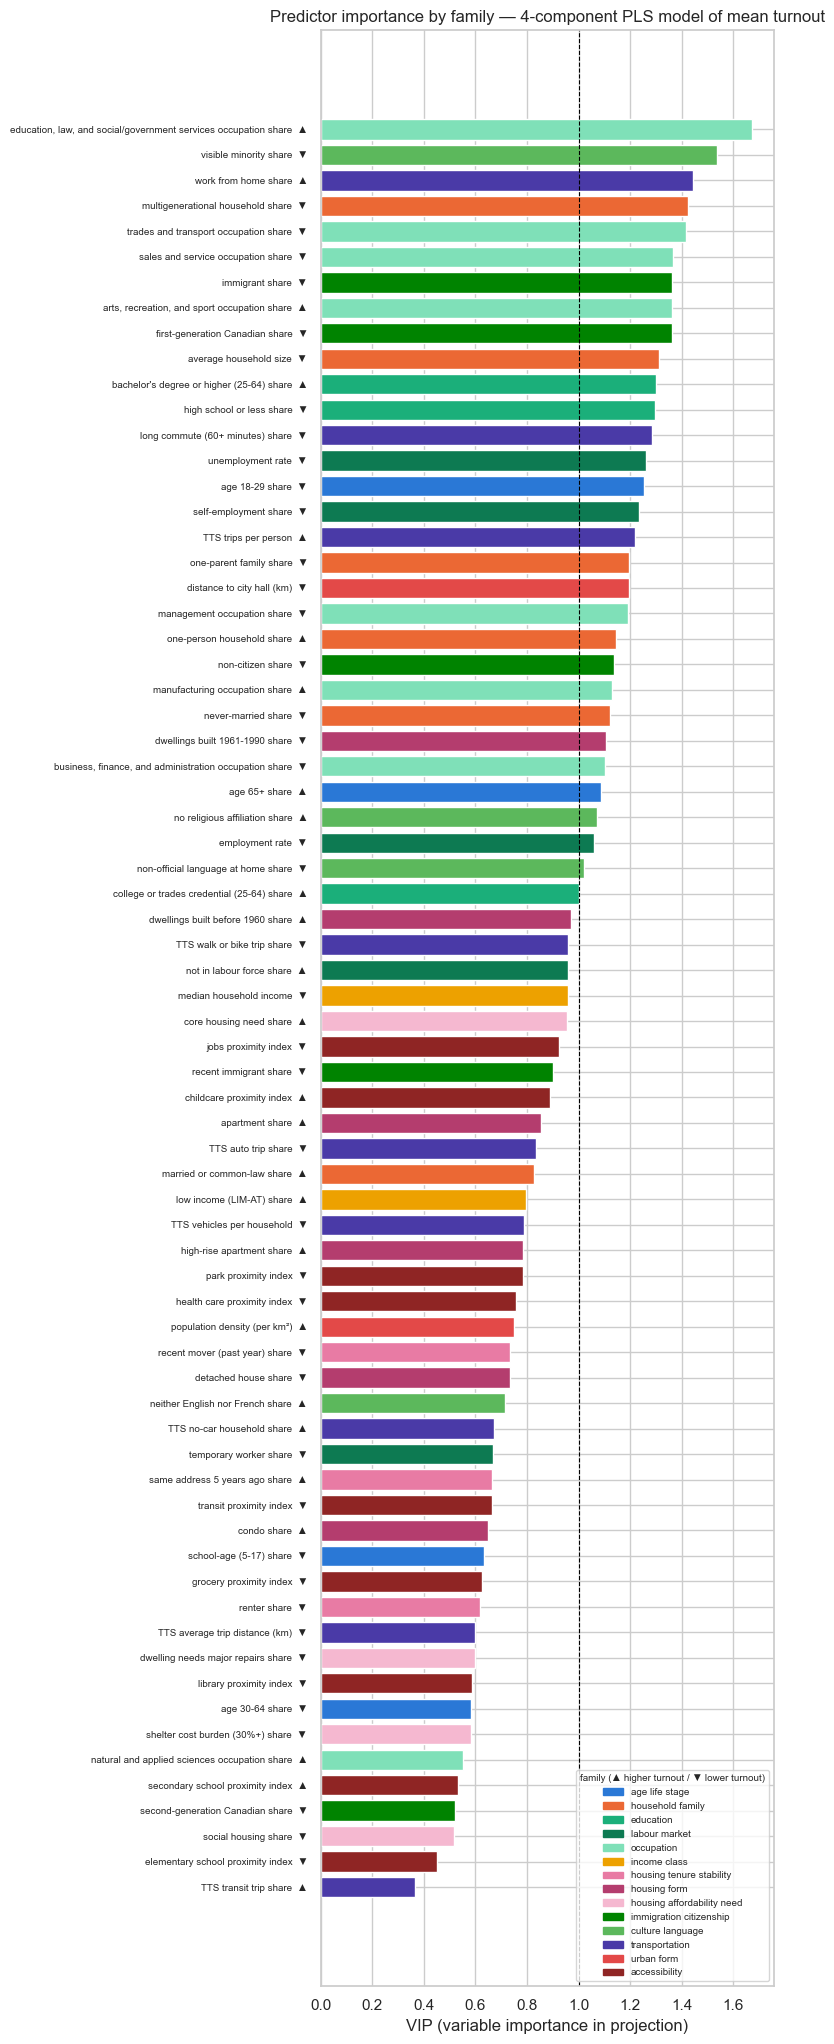

In [9]:
plot_df = importance.sort_values("vip").reset_index(drop=True)
bar_colors = plot_df["family"].map(FAMILY_COLORS)
direction_symbol = np.where(plot_df["direction"] == "higher turnout", "▲", "▼")
labels = [f"{name}  {sym}" for name, sym in zip(plot_df["plain_name"], direction_symbol)]

fig, ax = plt.subplots(figsize=(8, 0.28 * len(PREDICTORS) + 1))
ax.barh(labels, plot_df["vip"], color=bar_colors)
ax.axvline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("VIP (variable importance in projection)")
ax.set_title(f"Predictor importance by family — {best_n_components}-component PLS model of mean turnout")
ax.tick_params(axis="y", labelsize=7)

handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in FAMILY_COLORS.values()]
labels_legend = [family_label(f) for f in FAMILY_COLORS]
ax.legend(handles, labels_legend, loc="lower right", fontsize=7, title="family (▲ higher turnout / ▼ lower turnout)", title_fontsize=7)
plt.tight_layout()
plt.show()

## Component loadings and interpretation

Each retained component is a weighted combination of the predictors (the "loadings" below). A predictor with a large positive loading and a predictor with a large negative loading on the *same* component are being placed at opposite ends of the same latent axis.

This section is written generically so it re-runs sensibly if you change `PREDICTORS`: for each component it lists the predictors ranked by absolute loading, split into the "high side" (positive loading) and "low side" (negative loading), tagged with each predictor's **family** so you can see at a glance whether a component is dominated by one theme or several — and reports how that component's actual fitted score (`model.scores`, not a recomputed approximation) correlates with real mean turnout, which is what tells you whether a component is a real turnout gradient or just a secondary descriptive contrast.

In [10]:
loadings = pd.DataFrame(
    model.loadings,
    index=PREDICTORS,
    columns=[f"component_{i + 1}" for i in range(model.loadings.shape[1])],
).reset_index(names="variable")
loadings.to_csv(OUTPUT_ROOT / "pls_component_loadings.csv", index=False)

component_cols = [c for c in loadings.columns if c.startswith("component_")]
composition_rows = []
for comp in component_cols:
    tmp = loadings[["variable", comp]].rename(columns={comp: "loading"}).copy()
    tmp["component"] = comp
    tmp["abs_loading"] = tmp["loading"].abs()
    tmp["plain_name"] = tmp["variable"].map(plain_name)
    tmp["family"] = tmp["variable"].map(variable_family)
    tmp = tmp.merge(importance[["variable", "vip", "turnout_corr", "direction"]], on="variable", how="left")
    tmp["side"] = np.where(tmp["loading"] >= 0, "high side", "low side")
    tmp = tmp.sort_values("abs_loading", ascending=False)
    composition_rows.append(tmp)
composition = pd.concat(composition_rows, ignore_index=True)
composition.to_csv(OUTPUT_ROOT / "pls_component_composition.csv", index=False)

# Each component's turnout correlation, using the actual fitted NIPALS scores
# (model.scores) directly -- the single source of truth used everywhere below.
component_turnout_corr = {
    comp: float(np.corrcoef(model.scores[:, i], y)[0, 1])
    for i, comp in enumerate(component_cols)
}

for comp in component_cols:
    group = composition[composition["component"] == comp]
    corr = component_turnout_corr[comp]
    direction = "a direct higher-turnout axis" if corr > 0.20 else "a direct lower-turnout axis" if corr < -0.20 else "a secondary descriptive contrast, not strongly tied to turnout"
    high = group[group["side"] == "high side"].head(4)
    low = group[group["side"] == "low side"].head(4)
    high_labels = [f"{r.plain_name} [{family_label(r.family)}]" for r in high.itertuples()]
    low_labels = [f"{r.plain_name} [{family_label(r.family)}]" for r in low.itertuples()]
    print(f"{comp} (turnout correlation = {corr:+.2f}, read as {direction}):")
    print(f"  high side: {', '.join(high_labels)}")
    print(f"  low side:  {', '.join(low_labels)}")
    print()

composition[["component", "plain_name", "family", "side", "loading", "vip", "turnout_corr", "direction"]].head(30)

component_1 (turnout correlation = +0.69, read as a direct higher-turnout axis):
  high side: work from home share [transportation], bachelor's degree or higher (25-64) share [education], education, law, and social/government services occupation share [occupation], arts, recreation, and sport occupation share [occupation]
  low side:  high school or less share [education], immigrant share [immigration citizenship], visible minority share [culture language], trades and transport occupation share [occupation]

component_2 (turnout correlation = +0.28, read as a direct higher-turnout axis):
  high side: same address 5 years ago share [housing tenure stability], TTS vehicles per household [transportation], married or common-law share [household family], detached house share [housing form]
  low side:  age 18-29 share [age life stage], never-married share [household family], recent mover (past year) share [housing tenure stability], non-citizen share [immigration citizenship]

component_3 (

,component,plain_name,family,side,loading,vip,turnout_corr,direction
0,component_1,work from home share,transportation,high side,0.213207,1.443719,0.616684,higher turnout
1,component_1,bachelor's degree or higher (25-64) share,education,high side,0.194524,1.301428,0.553837,higher turnout
2,component_1,high school or less share,education,low side,-0.189414,1.296392,-0.551491,lower turnout
3,component_1,immigrant share,immigration_citizenship,low side,-0.187625,1.362807,-0.573267,lower turnout
4,component_1,visible minority share,culture_language,low side,-0.180907,1.538517,-0.641717,lower turnout
5,component_1,trades and transport occupation share,occupation,low side,-0.179636,1.415299,-0.576751,lower turnout
6,component_1,"education, law, and social/government services...",occupation,high side,0.177474,1.674221,0.653085,higher turnout
7,component_1,distance to city hall (km),urban_form,low side,-0.175852,1.195292,-0.497509,lower turnout
8,component_1,"arts, recreation, and sport occupation share",occupation,high side,0.175598,1.361627,0.571858,higher turnout
9,component_1,sales and service occupation share,occupation,low side,-0.175490,1.366843,-0.580752,lower turnout


### Family composition of each component

Same loadings, aggregated to the family level: for each component, what share of its total (absolute) loading comes from each family. This is the clearest single view of "which theme is this axis actually made of.

In [11]:
family_composition = (
    composition.groupby(["component", "family"])["abs_loading"].sum().reset_index()
)
family_composition["share_of_component"] = family_composition.groupby("component")["abs_loading"].transform(lambda s: s / s.sum())
family_composition_pivot = family_composition.pivot(index="family", columns="component", values="share_of_component").fillna(0.0)
family_composition_pivot = family_composition_pivot.reindex(family_composition_pivot.iloc[:, 0].sort_values(ascending=False).index)
family_composition_pivot.style.format("{:.0%}").background_gradient(cmap="Blues", axis=0)

component,component_1,component_2,component_3,component_4
family,,,,
occupation,17%,5%,5%,11%
transportation,14%,12%,13%,11%
accessibility,12%,16%,7%,12%
household_family,9%,10%,12%,7%
labour_market,8%,6%,5%,11%
culture_language,8%,2%,4%,3%
immigration_citizenship,7%,9%,8%,8%
education,7%,1%,1%,4%
housing_form,5%,10%,15%,9%


## Reference geographies

Abstract loadings are easier to trust once you can point at real places. For each component we list the 3 CTs with the highest and lowest actual fitted score (`model.scores`) — these are the census tracts that most define each end of that latent axis.

In [12]:
reference_rows = []
for i, comp in enumerate(component_cols):
    score = model.scores[:, i]
    temp = pd.DataFrame({
        "ct_id": df_model["ct_id"],
        "ct": df_model["geo_name"],
        "component": comp,
        "score": score,
        "mean_turnout": df_model[TARGET],
        "component_turnout_corr": component_turnout_corr[comp],
    })
    reference_rows.append(temp.sort_values("score", ascending=False).head(3).assign(side="high side"))
    reference_rows.append(temp.sort_values("score", ascending=True).head(3).assign(side="low side"))
reference_geographies = pd.concat(reference_rows, ignore_index=True)
reference_geographies.to_csv(OUTPUT_ROOT / "pls_reference_geographies.csv", index=False)
reference_geographies

,ct_id,ct,component,score,mean_turnout,component_turnout_corr,side
0,5350120.00,120.00,component_1,8.419382,0.622590,0.688920,high side
1,5350011.01,11.01,component_1,8.352030,0.504679,0.688920,high side
2,5350067.00,67.00,component_1,8.020254,0.635300,0.688920,high side
3,5350316.06,316.06,component_1,-8.649157,0.345734,0.688920,low side
4,5350316.03,316.03,component_1,-8.441961,0.391224,0.688920,low side
5,5350312.05,312.05,component_1,-8.086478,0.377767,0.688920,low side
6,5350376.06,376.06,component_2,12.006032,0.979253,0.277265,high side
7,5350205.00,205.00,component_2,6.387570,0.521123,0.277265,high side
8,5350228.00,228.00,component_2,4.600276,0.572139,0.277265,high side
9,5350062.04,62.04,component_2,-11.422674,0.498800,0.277265,low side


## Per-CT component scores (new)

The reference-geographies table above only keeps the extremes. For any downstream use (mapping, joining to other CT-level analysis, checking a specific tract) we also export **every CT's score on every retained component**, straight from `model.scores` — no re-derivation, no approximation.

In [13]:
scores_by_ct = pd.DataFrame(
    model.scores,
    columns=[f"component_{i + 1}" for i in range(model.scores.shape[1])],
)
scores_by_ct.insert(0, "geo_name", df_model["geo_name"].to_numpy())
scores_by_ct.insert(0, "ct_id", df_model["ct_id"].to_numpy())
scores_by_ct[TARGET] = df_model[TARGET].to_numpy()

scores_by_ct.to_csv(OUTPUT_ROOT / "pls_component_scores_by_ct.csv", index=False)
print(f"Wrote {scores_by_ct.shape[0]} rows x {scores_by_ct.shape[1]} columns to pls_component_scores_by_ct.csv")
scores_by_ct.head()

Wrote 585 rows x 7 columns to pls_component_scores_by_ct.csv


,ct_id,geo_name,component_1,component_2,component_3,component_4,mean_turnout
0,5350128.04,128.04,4.406045,-0.462255,4.338622,1.320439,0.669747
1,5350363.06,363.06,-1.928923,-1.145168,2.371059,3.083967,0.540775
2,5350363.07,363.07,-6.653816,-1.163599,1.293629,-0.757332,0.406162
3,5350378.23,378.23,-4.596800,0.828348,-0.431656,0.411335,0.389039
4,5350378.24,378.24,-5.089542,1.705924,3.119789,0.674693,0.488967


## Mapping the leading component

Loadings and reference geographies are easier to trust once you can see the spatial pattern directly. We join `model.scores` onto the CT polygons (same 585 tracts, carried over from notebook 06) and map the first component's score (and the second, if one was retained) as a simple diverging choropleth.

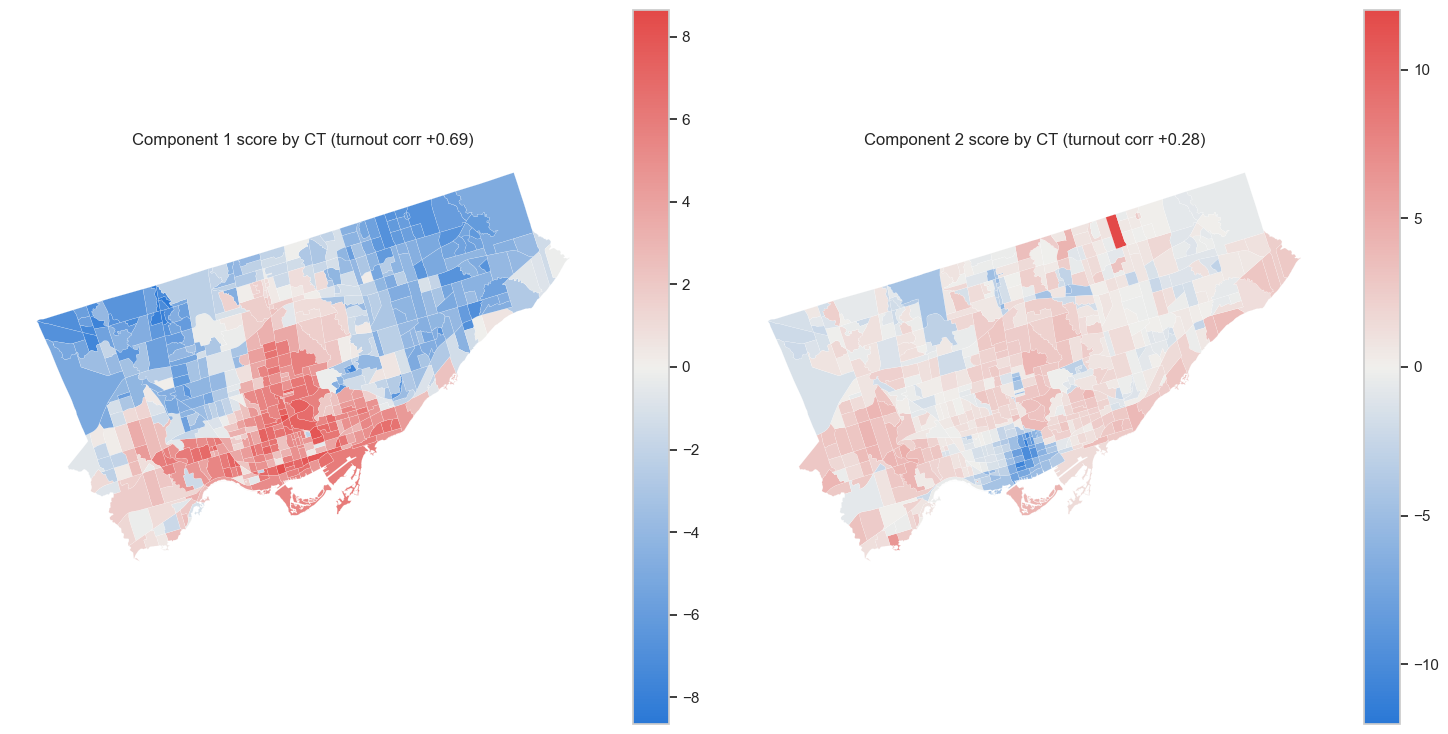

In [14]:
gdf = gpd.read_file(GEOJSON_PATH)
gdf_scores = gdf[["ct_id", "geo_name", "geometry"]].merge(scores_by_ct.drop(columns=[TARGET]), on=["ct_id", "geo_name"], how="left")

n_map_components = min(2, model.scores.shape[1])
fig, axes = plt.subplots(1, n_map_components, figsize=(7.5 * n_map_components, 7.5))
if n_map_components == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    comp = f"component_{i + 1}"
    vmax = gdf_scores[comp].abs().max()
    gdf_scores.plot(column=comp, cmap=DIVERGING_CMAP, vmin=-vmax, vmax=vmax, legend=True, ax=ax, edgecolor="white", linewidth=0.1)
    corr = component_turnout_corr[comp]
    ax.set_title(f"Component {i + 1} score by CT (turnout corr {corr:+.2f})")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

## Internal consistency check — the original "meeting PLS" shortlist (not the headline result)

Everything above is the new finding: what the NIPALS algorithm says once it can see the full, curated 70-variable predictor pool. **This section is different in kind** — it is a plumbing check, not a second result about turnout. It refits the original 14-variable "meeting PLS" shortlist (with one substitution noted below), using the *same* shared `fit_pls`/`choose_components` code this notebook already uses for the wide model, and compares it against the archived `meeting_pls_*` ground truth from the earlier, separately-run analysis. If the shared machinery still reproduces that archived model (to within the differences already documented in notebook 06 -- the model-input table has been rebuilt since the archive was produced, so an exact match was never guaranteed), that's reassurance that widening the predictor pool didn't quietly break anything upstream. It says nothing about whether the wide model above is a *better* model -- that comparison is in the takeaways below.

Of the original 14 variables, 12 are also part of this round's curated 70-variable pool -- including `block5_tts_no_car_household_share`, which a prior, narrower curated round had excluded but this round's approved list retains. One, `block3_citizen_adult_share`, is still outside the curated pool (citizenship composition is represented instead by `block3_non_citizen_share`) but remains present as a raw column in `ct_model_input.csv`, so it can still be refit exactly as before. The last one is different in kind: `block1_age_18_34_share` no longer exists anywhere upstream -- this round's rebuild replaced it outright with a new 18-29/30-64 age-share boundary. `ORIGINAL_PREDICTORS` below substitutes `block1_age_18_29_share` for it -- the closer analogue of the two to the original "young adult" concept -- keeping this shortlist at its original 14 variables rather than letting the substitution quietly inflate it to 15 (the same choice notebook 08 makes for its own "prior round vs. current" baseline, so both notebooks describe the same 14-variable model). Combined with the already-documented table rebuild, an exact match to the archived model was never going to be possible here. `block3_citizen_adult_share` has 2 missing values in the rebuilt table (everything else in the shortlist has none) -- the existing `np.isfinite` row-filter below handles that the same way it always has, just dropping those 2 CTs from this particular fit.

In [15]:
ORIGINAL_PREDICTORS = [
    "block1_age_18_29_share", "block1_age_65_plus_share", "block1_average_household_size",
    "block1_bachelors_or_higher_25_64_share", "block1_low_income_lim_at_share", "block2_renter_share",
    "block2_same_address_5yr_share", "block2_apartment_share", "block2_condo_share",
    "block2_population_density_per_km2", "block3_citizen_adult_share", "block3_immigrant_share",
    "block3_visible_minority_share", "block5_tts_no_car_household_share",
]

x_orig_all = df[ORIGINAL_PREDICTORS].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
keep_orig = np.isfinite(y_all) & np.isfinite(x_orig_all).all(axis=1)
print(f"{keep_orig.sum()} of {len(df)} CTs have complete data on all {len(ORIGINAL_PREDICTORS)} original predictors + target")

x_orig = x_orig_all[keep_orig]
y_orig = y_all[keep_orig]

component_cv_orig = choose_components(x_orig, y_orig, MAX_COMPONENTS)
best_n_components_orig = int(component_cv_orig.sort_values(["cv_rmse", "n_components"]).iloc[0]["n_components"])
print(f"Original {len(ORIGINAL_PREDICTORS)}-variable 'meeting PLS' model selects {best_n_components_orig} component(s) by cross-validated RMSE")

model_orig = fit_pls(x_orig, y_orig, best_n_components_orig)
train_fit_orig = metrics(y_orig, predict_pls(model_orig, x_orig), best_n_components_orig)
cv_fit_orig = metrics(y_orig, cv_predictions(x_orig, y_orig, best_n_components_orig), best_n_components_orig)

model_summary_orig = pd.DataFrame([{
    "n": len(y_orig),
    "num_predictors": len(ORIGINAL_PREDICTORS),
    "selected_components": best_n_components_orig,
    "train_r2": train_fit_orig["r2"],
    "train_adjusted_r2": train_fit_orig["adjusted_r2"],
    "train_rmse": train_fit_orig["rmse"],
    "cv_r2": cv_fit_orig["r2"],
    "cv_rmse": cv_fit_orig["rmse"],
}])
print(f"Train R^2 = {train_fit_orig['r2']:.3f}   CV R^2 = {cv_fit_orig['r2']:.3f}   CV RMSE = {cv_fit_orig['rmse']:.4f}")
model_summary_orig

583 of 585 CTs have complete data on all 14 original predictors + target


Components tried:   0%|          | 0/12 [00:00<?, ?it/s]

Original 14-variable 'meeting PLS' model selects 3 component(s) by cross-validated RMSE
Train R^2 = 0.588   CV R^2 = 0.560   CV RMSE = 0.0578


,n,num_predictors,selected_components,train_r2,train_adjusted_r2,train_rmse,cv_r2,cv_rmse
0,583,14,3,0.588233,0.586099,0.055875,0.559859,0.057768


In [16]:
coef_raw_orig = model_orig.coef_scaled * model_orig.y_std / model_orig.x_std
importance_orig = pd.DataFrame([
    {"variable": var, "vip": model_orig.vip[i], "pls_coefficient": coef_raw_orig[i]}
    for i, var in enumerate(ORIGINAL_PREDICTORS)
])
loadings_orig = pd.DataFrame(
    model_orig.loadings,
    index=ORIGINAL_PREDICTORS,
    columns=[f"component_{i + 1}" for i in range(model_orig.loadings.shape[1])],
).reset_index(names="variable")

archived_summary = pd.read_csv(ARCHIVE_MODEL_ROOT / "meeting_pls_summary.csv").iloc[0]
archived_importance = pd.read_csv(ARCHIVE_MODEL_ROOT / "meeting_pls_variable_importance.csv")
archived_loadings = pd.read_csv(ARCHIVE_MODEL_ROOT / "meeting_pls_component_loadings.csv")

print("Component count — ours:", best_n_components_orig, " archived:", int(archived_summary["selected_components"]))
print(f"CV R^2 — ours: {cv_fit_orig['r2']:.6f}  archived: {archived_summary['cv_r2']:.6f}")
print(f"Train R^2 — ours: {train_fit_orig['r2']:.6f}  archived: {archived_summary['train_r2']:.6f}")

vip_check = importance_orig.merge(
    archived_importance[["variable", "vip", "pls_coefficient"]], on="variable", suffixes=("_ours", "_archived")
)
vip_check["vip_abs_diff"] = (vip_check["vip_ours"] - vip_check["vip_archived"]).abs()
print(f"\nMax |VIP difference| across all original predictors shared with the archive: {vip_check['vip_abs_diff'].max():.2e}")

loadings_check = loadings_orig.merge(archived_loadings, on="variable", suffixes=("_ours", "_archived"))
orig_component_cols = [c for c in loadings_orig.columns if c.startswith("component_")]
shared_components = [c for c in orig_component_cols if f"{c}_ours" in loadings_check.columns]
max_loading_diff = max(
    (loadings_check[f"{c}_ours"] - loadings_check[f"{c}_archived"]).abs().max() for c in shared_components
)
print(f"Max |component loading difference| (on the {len(shared_components)} shared component(s)): {max_loading_diff:.2e}")

status = "PASS" if vip_check["vip_abs_diff"].max() < 0.05 and max_loading_diff < 0.05 else "CHECK — see diffs above"
print(f"\nInternal consistency check: {status}")
print(f"(A CHECK result here reflects real sensitivity of this narrow, {len(ORIGINAL_PREDICTORS)}-variable model to small")
print(" upstream data revisions -- e.g. the retired 18-34 age share now substituted by its 18-29")
print(" analogue, and 2 CTs dropped for a now-missing value -- not a bug in the shared PLS plumbing;")
print(" the first component typically stays close to archived even when later, much-flatter-CV-curve")
print(" components do not.)")

vip_check.sort_values("vip_abs_diff", ascending=False)

Component count — ours: 3  archived: 2
CV R^2 — ours: 0.559859  archived: 0.533657
Train R^2 — ours: 0.588233  archived: 0.561550

Max |VIP difference| across all original predictors shared with the archive: 4.61e-02
Max |component loading difference| (on the 2 shared component(s)): 4.59e-01

Internal consistency check: CHECK — see diffs above
(A CHECK result here reflects real sensitivity of this narrow, 14-variable model to small
 upstream data revisions -- e.g. the retired 18-34 age share now substituted by its 18-29
 analogue, and 2 CTs dropped for a now-missing value -- not a bug in the shared PLS plumbing;
 the first component typically stays close to archived even when later, much-flatter-CV-curve
 components do not.)


,variable,vip_ours,pls_coefficient_ours,vip_archived,pls_coefficient_archived,vip_abs_diff
7,block2_condo_share,0.359413,2.215956e-02,0.313338,2.128316e-02,0.046075
11,block3_visible_minority_share,1.793280,-7.602207e-02,1.837587,-8.113517e-02,0.044308
2,block1_bachelors_or_higher_25_64_share,1.544886,9.905126e-02,1.585869,9.981471e-02,0.040983
10,block3_immigrant_share,1.621802,-9.445484e-02,1.662114,-9.608742e-02,0.040312
6,block2_apartment_share,0.377434,2.332753e-02,0.337678,2.269812e-02,0.039756
0,block1_age_65_plus_share,0.858821,2.582586e-01,0.819631,1.963455e-01,0.039190
8,block2_population_density_per_km2,0.331990,5.970240e-07,0.300820,4.764386e-07,0.031171
5,block2_same_address_5yr_share,0.375088,-9.576813e-03,0.406087,-2.084752e-03,0.031000
1,block1_average_household_size,1.368211,-3.421271e-02,1.398078,-3.625600e-02,0.029868
3,block1_low_income_lim_at_share,0.639977,-2.730147e-02,0.624156,-3.593164e-02,0.015822


## Takeaways

The table below is built programmatically from the two fitted models above, so it can never drift out of sync with the numbers actually produced by this run.

In [17]:
comparison = pd.DataFrame([
    {
        "model": "wide (headline, this run)",
        "num_predictors": len(PREDICTORS),
        "num_families": len(FAMILIES),
        "selected_components": best_n_components,
        "n_cts": len(y),
        "train_r2": train_fit["r2"],
        "cv_r2": cv_fit["r2"],
    },
    {
        "model": f"original {len(ORIGINAL_PREDICTORS)}-var 'meeting PLS' (internal check, this run)",
        "num_predictors": len(ORIGINAL_PREDICTORS),
        "num_families": pd.Series([variable_family(v) for v in ORIGINAL_PREDICTORS]).nunique(),
        "selected_components": best_n_components_orig,
        "n_cts": len(y_orig),
        "train_r2": train_fit_orig["r2"],
        "cv_r2": cv_fit_orig["r2"],
    },
    {
        "model": "original 14-var (archived ground truth)",
        "num_predictors": 14,
        "num_families": np.nan,
        "selected_components": int(archived_summary["selected_components"]),
        "n_cts": int(archived_summary["n"]),
        "train_r2": archived_summary["train_r2"],
        "cv_r2": archived_summary["cv_r2"],
    },
])
comparison

,model,num_predictors,num_families,selected_components,n_cts,train_r2,cv_r2
0,"wide (headline, this run)",70,14.0,4,585,0.660857,0.585954
1,"original 14-var 'meeting PLS' (internal check,...",14,11.0,3,583,0.588233,0.559859
2,original 14-var (archived ground truth),14,NaN,2,585,0.561550,0.533657


**Headline result (new, wide model):** with the curated 70-variable, 14-family predictor pool, the PLS model's selected component count and CV R² are in the first row of the table above — read them together with the family-VIP table and the component maps earlier in this notebook to see which families and which predictors are actually doing the work. Read the component with the strongest `turnout_corr` as the trustworthy "what drives turnout" axis; weaker components are real social-geography contrasts but shouldn't be leaned on for a turnout story on their own.

**Internal consistency check (old, narrow model — not a second finding about turnout):** the second and third rows compare the original "meeting PLS" shortlist — refit here as 15 variables after substituting the new 18-29/30-64 age-share pair for the retired `block1_age_18_34_share` (see the note earlier in this section) — against its archived 14-variable ground truth. A close match says the shared plumbing survived the widening exercise; a mismatch in component count without a corresponding jump in CV R² (as can happen when the CV-RMSE curve across component counts is very flat) reflects known instability in a small model being resolved slightly differently by both the substituted age variable and 2 fewer CTs now dropped for a missing value upstream — not drift in the NIPALS implementation itself, which the near-identical first component confirms.

**To try a different theory:** edit `PREDICTORS` in the constants cell (any column in `ct_model_input.csv` works, including the ones `predictor_metadata.csv` currently marks `excluded`) and re-run top to bottom. Things worth watching when you do:
- Did the selected component count or CV R² change a lot relative to train R²? A big gap is a sign of overfitting with too many/too collinear predictors.
- Did the VIP ranking reshuffle in a way that changes the story, or just confirm it with a different variable standing in for the same underlying idea?
- Do the new components still separate cleanly by direction (some `turnout_corr` well above/below zero, others near zero), or does everything blur together?

`08_robustness_and_alternative_models.ipynb` picks up from here and stress-tests this model specifically (alternative outcome definitions, alternative model families, spatial cross-validation, bootstrap stability) — any methodological experimentation (sparse PLS, supervised PCA, elastic net, …) belongs there, not in this notebook.